In [23]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
#mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove

metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
#metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered


# steps needed before 
se notebook  to create cum BMB table : 'get cumulative BMB 2100 ,2200 2300'

In [24]:
df_best = pd.read_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/best_ms_method_per_model.csv')

# use notebook TABLES to create cum BMB : 'get cumulative BMB 2100 ,2200 2300'
# imau data from Helene replaced
df_bmb2100 = pd.read_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/cumulative_shelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/cumulative_shelfmelt_2100.csv')
df_bmb2300 = pd.read_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/cumulative_shelfmelt_2200.csv')

dfds = [
df_bmb2100,
df_bmb2200,
df_bmb2300,
]
# renaming regions if they are not consitent with other tables:

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    df_ms['Aurora']=df_ms['sector_8']
    df_ms ['Wilkes']=df_ms['sector_7']
    
regions = ['AIS',
 'Amundsen',
 'Ross',
 'FilchnerRonne',
           'Aurora',
           'Wilkes'
    ]
regions_keys ={}
regions_keys['AIS'] = ['']

regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']
regions_keys['Aurora']= ['_sector_8']
regions_keys['Wilkes']= ['_sector_7']

Models = df_best.Model.values

In [25]:
factor = -1*365.25 *24*60*60/10**12 #Gt/a

### old group from shelf area



In [26]:
regions

['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']

In [27]:
#### Putting all models into three

In [31]:
new_path

'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/ComputedScalarsHelene/'

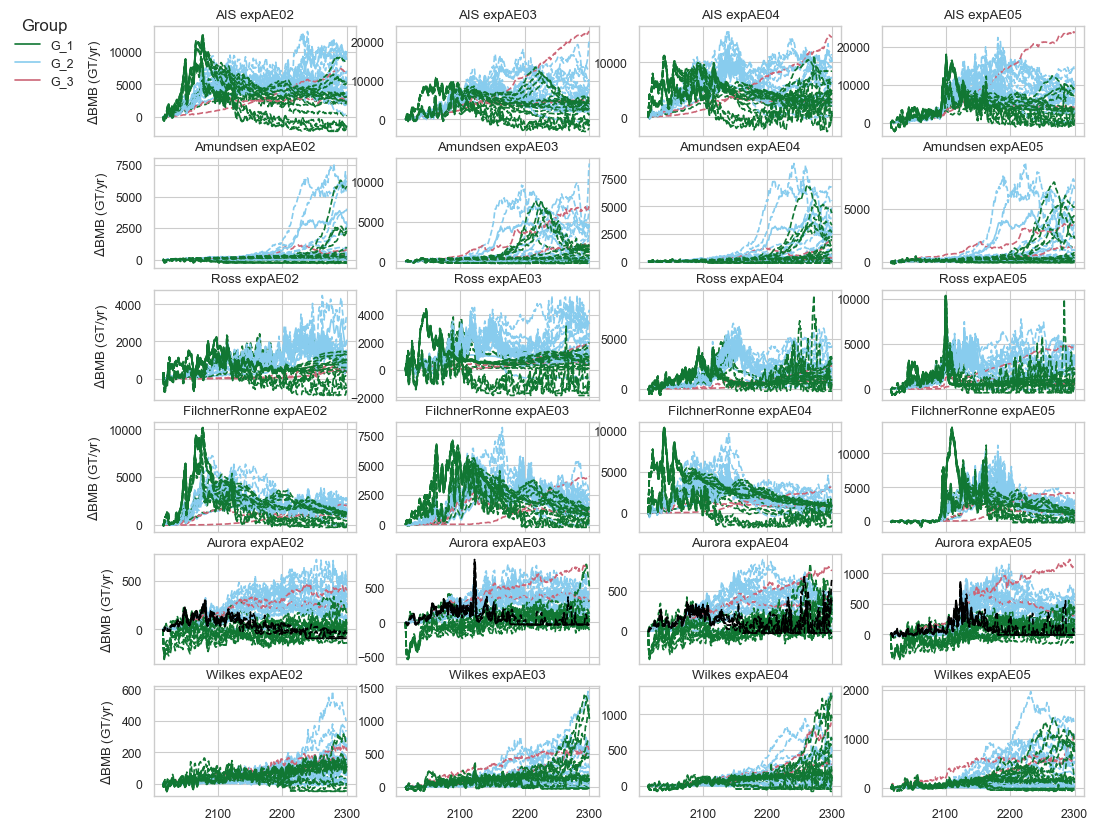

In [34]:
# Test with pic:

models_group1=['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3' ,'VUW_PISM1_s4' ,'VUW_PISM2',\
               'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4', 'PIK_PISM', 'LSCE_GRISLI2' ,\
               'LSCE_GRISLI','UCM_Yelmo','IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3' ,'IMAU_UFEMISM4' ]
models_group2 = ['DC_ISSM', 'ILTS_SICOPOLIS' ,'VUB_AISMPALEO','NCAR_CISM1' ,'NORCE_CISM3-MAR364-ERA-t1-nonlocal',\
                 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal','NCAR_CISM2',\
                 'NORCE_CISM3-MAR364-ERA-t1-local' ,'NORCE_CISM4-MAR364-ERA-t1-local' ,\
                 'NORCE_CISM5-MAR364-ERA-t1-local', 'UNN_Ua','NORCE_CISM2-MAR364-ERA-t1',\
                 'NORCE_CISM3-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1',\
                 'NORCE_CISM5-MAR364-ERA-t1','UTAS_ElmerIce','ULB_fETISh-KoriBU2','IGE_ElmerIce','DOE_MALI_4km', 'DOE_MALI_8km_Ant95' ,'DOE_MALI_8km_AntMean',\
                ]
models_group4 =['ULB_fETISh-KoriBU1', 'UCSD_ISSM']

models_groups = [models_group1,models_group2,models_group4]

n = 0

all_model_groups = []
for group in models_groups:
    for m in group:
        all_model_groups.append(m)
    n= n+len(group);
    

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in all_model_groups:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            

models_group5=[ ]

all_groups =[models_group1,models_group2,models_group4]


# cols_u = ['black','blue','fuchsia','green']
cols_u = ['#117733', '#88CCEE', '#CC6677']


groups_cat = np.zeros_like(Models)

for i,Model in enumerate(Models):
    for j, group in enumerate(all_groups):
        for gmodel in group:
           
            if gmodel == Model:
                groups_cat[i]=j
                
groups_cat
regions =['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']
dic_colors_groupcat = {}
for i in range(3):
    key = 'G_'+str(i+1)
    dic_colors_groupcat[key]=cols_u[i]

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_groupcat.items()]


f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10),sharex=True)
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    if i == 4:
        continue
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            #new_path =   df_model.Path.values[0]
            new_path = f'{pth_helene}/{exp}/shelfmelt/computed_shelfmelt_AIS_{Model}_{exp}.nc'
#             if Model.startswith('IMAU'):
#                 print(new_path)
#                 new_path=new_path.replace('computed_shelfmelt_','jb_computed_shelfmelt_')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values*factor
                y = y+melt
            y = y-y[0]
            col = cols_u[groups_cat[k]]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            if (Model == 'IGE_ElmerIce') or Model ==('ULB_fETISh-KoriBU2'):
                ax.plot(d.time.values,y,color = col,linestyle = '-' )
            else:
           
                ax.plot(d.time.values,y,color = col,linestyle = '--' )
        ax.set_title(f'{region} {exp}')  
    ax2[i,0].set_ylabel('$\Delta$BMB (GT/yr)')
    
# Test with pic:

models_group1=['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3' ,'VUW_PISM1_s4' ,'VUW_PISM2',\
               'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4', 'PIK_PISM', 'LSCE_GRISLI2' ,\
               'LSCE_GRISLI','UCM_Yelmo']
models_group2 = ['DC_ISSM', 'ILTS_SICOPOLIS' ,'VUB_AISMPALEO','NCAR_CISM1' ,'NORCE_CISM3-MAR364-ERA-t1-nonlocal',\
                 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal','NCAR_CISM2',\
                 'NORCE_CISM3-MAR364-ERA-t1-local' ,'NORCE_CISM4-MAR364-ERA-t1-local' ,\
                 'NORCE_CISM5-MAR364-ERA-t1-local', 'UNN_Ua','NORCE_CISM2-MAR364-ERA-t1',\
                 'NORCE_CISM3-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1',\
                 'NORCE_CISM5-MAR364-ERA-t1','UTAS_ElmerIce','ULB_fETISh-KoriBU2','IGE_ElmerIce',\
                 'DOE_MALI_4km', 'DOE_MALI_8km_Ant95' ,'DOE_MALI_8km_AntMean']
models_group4 =['ULB_fETISh-KoriBU1', 'UCSD_ISSM']
models_group3 =['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3' ,'IMAU_UFEMISM4' ]



models_groups = [models_group1,models_group2,models_group4]

n = 0

all_model_groups = []
for group in models_groups:
    for m in group:
        all_model_groups.append(m)
    n= n+len(group);
    

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in all_model_groups:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            

models_group5=[ ]

all_groups =[models_group1,models_group2,models_group4,models_group3]


# cols_u = ['black','blue','fuchsia','grey']
cols_u = ['#117733', '#88CCEE', '#CC6677','black']


groups_cat = np.zeros_like(Models)

for i,Model in enumerate(Models):
    for j, group in enumerate(all_groups):
        for gmodel in group:
           
            if gmodel == Model:
                groups_cat[i]=j
regionsa = ['Aurora']               
for i,region in  enumerate(regionsa):
    i = 4
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
#         ax = ax2[i,j]
        ax = ax2[i,j]
        
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            # new_path =   df_model.Path.values[0]
            new_path = f'{pth_helene}/{exp}/shelfmelt/computed_shelfmelt_AIS_{Model}_{exp}.nc'
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values*factor
                y = y+melt
            y = y-y[0]
            col = cols_u[groups_cat[k]]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            if (Model == 'IGE_ElmerIce') or Model ==('ULB_fETISh-KoriBU2'):
                ax.plot(d.time.values,y,color = col,linestyle = '-' )
            else:
           
                ax.plot(d.time.values,y,color = col,linestyle = '--' )
                ax.set_title(f'{region} {exp}')  
    ax2[i,0].set_ylabel('$\Delta$BMB (GT/yr)')
   
f.legend(handles=legend_elements, title='Group', loc='upper left', bbox_to_anchor=(0., 0.9), fontsize=9, title_fontsize=12,frameon=False)
f.savefig('figs/paper/Fig5.pdf')
f.savefig('figs/paper/Fig5.jpeg')

In [32]:
Models

array(['DC_ISSM', 'DOE_MALI_4km', 'DOE_MALI_8km_Ant95',
       'DOE_MALI_8km_AntMean', 'IGE_ElmerIce', 'ILTS_SICOPOLIS',
       'LSCE_GRISLI2', 'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO',
       'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3',
       'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2',
       'VUW_PISM2_s3', 'VUW_PISM2_s4', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2',
       'IMAU_UFEMISM3', 'IMAU_UFEMISM4'], dtype=object)

In [35]:
regions = [ 'Amundsen',   'Wilkes']
Models_1 = Models

mask_special_model =Models=='notamodel'
mask_special_model = ~mask_special_model
for i,Model in enumerate(Models):
    if  Model.startswith('VUW_PISM'):
     
        mask_special_model[i]= ~mask_special_model[i]
            


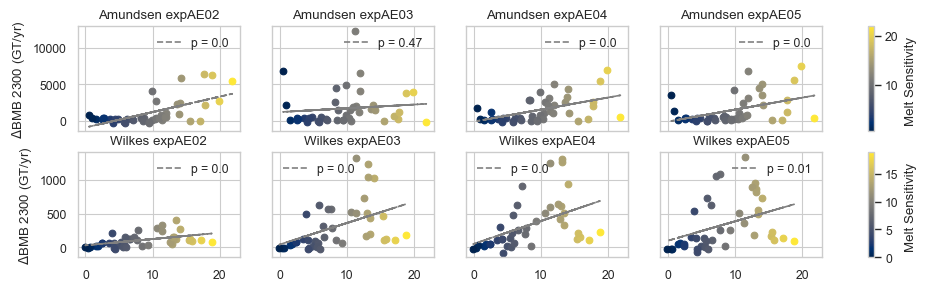

In [48]:
# 1.  MH Quad. Non-local 


mask_special_model =Models=='notamodel'
mask_special_model = ~mask_special_model
# for i,Model in enumerate(Models):
#     if  Model.startswith('VUW_PISM'):
     
#         mask_special_model[i]= ~mask_special_model[i]
            
Models_1=Models[mask_special_model]            
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,3),sharex =True,sharey ='row')
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=np.nanmin(ms_models), vmax=np.nanmax(ms_models))
    
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('cividis')
    colors = cmap(normalized_ms)
    sm = plt.cm.ScalarMappable(cmap='cividis', norm=norm)
    sm.set_array([])  # Needed for the colorbar


    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        bmb_2300 = []
        ms_model = []
        for k,Model in enumerate(Models_1):
            df_model = df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            #new_path = df_model.Path.values[0]
            new_path = f'{pth_helene}/{exp}/shelfmelt/computed_shelfmelt_AIS_{Model}_{exp}.nc'
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values*factor
                y = y+melt
#             y = y/y[0]*100
            y = y-y[0]
            
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            Pre_mod = Model.split('_')[0]
            ax.scatter(ms,y[-1],color = col )
            ms_model.append(ms)
            bmb_2300.append(y[-1])
            mnan = ~np.isnan(ms_model)
        slope, intercept, r, p, se = linregress(np.asarray(ms_model)[mnan],np.asarray(bmb_2300)[mnan])
        y_calc= slope *np.asarray(ms_model) +intercept
        
        ax.plot(ms_model,y_calc,'--',color = 'gray', label = f'p = {np.round(p,2)}' )
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region} {exp}')  
        legend = ax.legend(frameon = False)
        for line in legend.get_lines():
            line.set_marker("")

        if j ==3:
            cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
            cbar.set_label(f'Melt Sensitivity ')
    ax2[i,0].set_ylabel('$\Delta$BMB 2300 (GT/yr)')
   
f.savefig('figs/paper/Fig6.pdf')
f.savefig('figs/paper/Fig6.jpeg')


